# Audit qualité du dataset maître CollectionLens

## Objectif

Évaluer la qualité du dataset maître construit à partir des différentes sources bibliographiques.

L'analyse vise à mesurer :

- la complétude des champs ;
- la couverture réelle des métadonnées ;
- la qualité des descriptions ;
- la qualité des catégories ;
- la disponibilité des couvertures ;
- la qualité des informations bibliographiques.

Cette étape permettra de déterminer si les données actuelles sont suffisantes pour les futures fonctionnalités de recommandation.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "master_dataset"
    / "collectionlens_master.csv"
)

df_master = pd.read_csv(DATASET_PATH)

df_master.shape

(1036, 21)

In [3]:
df_master.head()

,isbn,title,title_source,authors,authors_source,publisher,publisher_source,published_date,published_date_source,description,...,categories,categories_source,page_count,page_count_source,format,format_source,cover_url,cover_url_source,bnf_ark,bnf_ark_source
0,9782351420225,Satan 666,google_books,['Seishi Kishimoto'],google_books,Kurokawa (Paris),bnf,2005-10-13,google_books,Collection : Collection dirigée par Grégoire H...,...,NaN,NaN,184.0,google_books,"1 vol. (184 p.) : ill., couv. ill., jaquette i...",bnf,NaN,NaN,http://catalogue.bnf.fr/ark:/12148/cb40085004q,bnf
1,9782845800717,L'aube,google_books,['Osamu Tezuka'],google_books,Éd. Tonkam (Paris),bnf,2007-02-07,google_books,Le phénix est un oiseau immortel ! Une créatur...,...,NaN,NaN,339.0,google_books,"339 p. : ill., jaquette ill. en coul. ; 17 cm",bnf,NaN,NaN,http://catalogue.bnf.fr/ark:/12148/cb376291158,bnf
2,2910635169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9781421532271,"Color Bleach, Bleach",nudger,['Tite Kubo'],google_books,[Viz Media],nudger,2010-08-10,google_books,The Soul Reaper's Handbook This indispensable ...,...,['Comics & Graphic Novels'],google_books,184.0,nudger,Broché,nudger,http://books.google.com/books/content?id=I6Idn...,google_books,NaN,NaN
4,9782016284407,Laïcité,nudger,['Charb (1967-2015). Auteur du texte'],bnf,[Robinson],nudger,2025-01-02,google_books,"Je comprends qu&#39;on puisse être juif, chrét...",...,NaN,NaN,96.0,nudger,Album,nudger,NaN,NaN,http://catalogue.bnf.fr/ark:/12148/cb476267290,bnf


In [4]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   isbn                   1036 non-null   object 
 1   title                  1000 non-null   object 
 2   title_source           1000 non-null   object 
 3   authors                850 non-null    object 
 4   authors_source         850 non-null    object 
 5   publisher              982 non-null    object 
 6   publisher_source       982 non-null    object 
 7   published_date         894 non-null    object 
 8   published_date_source  894 non-null    object 
 9   description            822 non-null    object 
 10  description_source     822 non-null    object 
 11  categories             76 non-null     object 
 12  categories_source      76 non-null     object 
 13  page_count             984 non-null    float64
 14  page_count_source      984 non-null    object 
 15  form

## Analyse de complétude

Mesure du taux de remplissage de chaque champ du dataset maître.

In [5]:
completion = []

for column in df_master.columns:

    rate = (
        df_master[column]
        .notna()
        .mean()
        * 100
    )

    completion.append(
        {
            "field": column,
            "completion_rate": round(rate, 2),
        }
    )

completion_df = pd.DataFrame(
    completion
)

completion_df.sort_values(
    "completion_rate",
    ascending=False,
)

,field,completion_rate
0,isbn,100.00
1,title,96.53
2,title_source,96.53
13,page_count,94.98
14,page_count_source,94.98
5,publisher,94.79
6,publisher_source,94.79
16,format_source,87.93
15,format,87.93
7,published_date,86.29


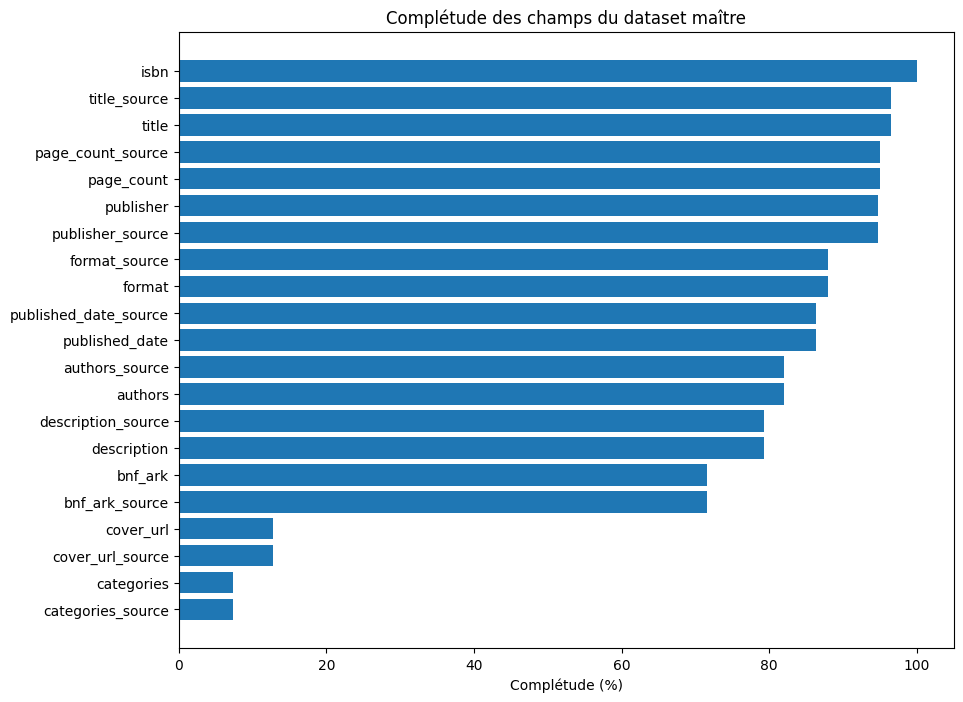

In [6]:
completion_df = completion_df.sort_values(
    "completion_rate",
    ascending=True,
)

plt.figure(figsize=(10, 8))

plt.barh(
    completion_df["field"],
    completion_df["completion_rate"],
)

plt.xlabel("Complétude (%)")
plt.title("Complétude des champs du dataset maître")

plt.show()

## Audit des features

### Analyse du champ title

Complétude observée :

- 96,53 % de titres disponibles ;
- 996 titres provenant de Nudger ;
- 4 titres provenant de Google Books ;
- 36 titres manquants.

Répartition des sources :

| Source | Nombre |
|----------|----------:|
| Nudger | 996 |
| Google Books | 4 |
| Valeur manquante | 36 |

L'analyse de l'échantillon montre que les titres sont globalement exploitables pour les futures fonctionnalités de recommandation.

Plusieurs anomalies de normalisation ont toutefois été observées :

- présence de suffixes "tome" ou "T01" ;
- mélange entre titre de série et titre de volume ;
- différences de casse ;
- présence ponctuelle d'informations éditoriales ou commerciales.

Le champ reste néanmoins de bonne qualité pour le POC.

Une normalisation complémentaire pourra être envisagée ultérieurement afin de séparer plus proprement les notions de série, volume et édition.

In [7]:
df_master["title_source"].value_counts(dropna=False)

title_source
nudger          996
NaN              36
google_books      4
Name: count, dtype: int64

In [8]:
df_master["title"].sample(
    50,
)

186                                     batman, le culte
379                                          Analog Drop
971                    Marvel heroes (5ème série) tome 1
532                    dr slump tome 1 - perfect edition
413                         l'homme qui tua nobunaga t01
510                                   L'Apprenti Mangaka
520                                ecole emportee - tome
172                              la saga de ra's al ghul
717                             l'arbre au soleil tome 1
283                            wataru - sauveur du monde
405                                   Fermat Kitchen T01
306                               continent du vent (le)
429                       Food Wars - Spécialité du chef
986              Fantastic four solo,01:mister fantastic
162                          Batman no man's land tome 1
560                   tezuka, histoires pour tous tome 1
252                              histoires de femmes t.1
968                            

### Analyse du champ authors

Complétude observée :

- 82,05 % d'auteurs disponibles ;
- 573 valeurs provenant de Google Books ;
- 277 valeurs provenant de la BNF ;
- 186 valeurs manquantes.

L'analyse qualitative montre que les auteurs issus de Google Books sont généralement bien normalisés et directement exploitables.

Les auteurs issus de la BNF sont plus riches bibliographiquement mais contiennent souvent des informations supplémentaires telles que les dates de naissance ou la mention "Auteur du texte".

Le champ est considéré comme suffisamment qualitatif pour les futures fonctionnalités de recommandation.

Une normalisation complémentaire des noms d'auteurs pourra être envisagée dans une version ultérieure afin d'harmoniser les formats entre les différentes sources.

In [9]:
df_master["authors_source"].value_counts(dropna=False)

authors_source
google_books    573
bnf             277
NaN             186
Name: count, dtype: int64

In [10]:
df_master[
    ["authors", "authors_source"]
].dropna().sample(
    50,
    random_state=42,
)

,authors,authors_source
653,"['Shiro Amano', 'Tetsuya Nomura']",google_books
494,"['Kitaoka, Tomo. Auteur du texte']",bnf
117,"['Kanazawa, Nobuaki (1982-....). Auteur du tex...",bnf
837,['Sean Gordon Murphy'],google_books
44,['Tsunina Miura'],google_books
73,"['Toriyama, Akira (1955-2024). Auteur du texte']",bnf
920,"['Lhote, Olivier (1965-....). Auteur du texte']",bnf
394,"['Itō, Junji (1963-....). Auteur du texte']",bnf
962,"['Ennis, Garth (1970-....). Auteur du texte']",bnf
606,['Kaoru Tada'],google_books


### Analyse du champ publisher

Complétude observée :

- 94,79 % d'éditeurs disponibles ;
- 919 valeurs provenant de Nudger ;
- 61 valeurs provenant de la BNF ;
- 2 valeurs provenant de Google Books ;
- 54 valeurs manquantes.

L'analyse qualitative montre que le champ contient correctement les principaux éditeurs de mangas, BD et comics.

Quelques anomalies de normalisation ont été identifiées :

- présence de crochets dans certaines valeurs issues de Nudger ;
- variantes de nommage pour certains éditeurs ;
- présence d'informations géographiques dans certaines valeurs issues de la BNF.

Le champ est néanmoins considéré comme de très bonne qualité pour les besoins du POC.

Une harmonisation des noms d'éditeurs pourra être envisagée dans une version ultérieure afin de faciliter les analyses statistiques et les regroupements.

In [11]:
df_master["publisher_source"].value_counts(dropna=False)

publisher_source
nudger          919
bnf              61
NaN              54
google_books      2
Name: count, dtype: int64

In [12]:
df_master[
    ["publisher", "publisher_source"]
].dropna().sample(
    50,
    random_state=42,
)

,publisher,publisher_source
860,[Urban Comics Editions],nudger
851,[Urban Comics Editions],nudger
912,[Fluide Glacial],nudger
545,[Glénat],nudger
70,[Glénat],nudger
867,[Urban Comics Editions],nudger
698,[Jungle],nudger
408,[Isan Manga],nudger
541,[Glénat],nudger
495,[Kana],nudger


### Analyse du champ published_date

Complétude observée :

- 86,29 % de dates disponibles ;
- 875 valeurs provenant de Google Books ;
- 19 valeurs provenant de la BNF ;
- 142 valeurs manquantes.

Le champ présente une excellente qualité globale.

Les formats observés sont cohérents avec les pratiques bibliographiques :

- année seule ;
- année-mois ;
- date complète.

Ces variations restent parfaitement exploitables pour les besoins du projet.

Le champ est considéré comme directement utilisable pour les futures fonctionnalités de recommandation et d'analyse temporelle.

In [13]:
df_master["published_date_source"].value_counts(dropna=False)

published_date_source
google_books    875
NaN             142
bnf              19
Name: count, dtype: int64

In [14]:
df_master[
    ["published_date", "published_date_source"]
].dropna().sample(
    50,
    random_state=42,
)

,published_date,published_date_source
838,2021-04-02,google_books
560,2006-05-24,google_books
646,2012-10-17,google_books
849,2025-01-24,google_books
44,2015-07-01,google_books
408,2022-09-09,google_books
418,2022-03-02,google_books
451,2008,google_books
213,2023,google_books
141,2011-03-25,google_books


### Analyse du champ description

Complétude observée :

- 79,34 % de descriptions disponibles ;
- 580 valeurs provenant de Google Books ;
- 242 valeurs provenant de la BNF ;
- 214 valeurs manquantes.

L'analyse qualitative montre une forte différence de qualité entre les sources.

Les descriptions issues de Google Books contiennent généralement de véritables résumés exploitables pour les futures fonctionnalités de recommandation.

À l'inverse, certaines descriptions issues de la BNF correspondent à des métadonnées bibliographiques (collections, codes EAN, informations d'édition) plutôt qu'à des résumés de contenu.

Le champ reste néanmoins exploitable pour le POC grâce à la forte contribution de Google Books.

Une étape de filtrage des descriptions bibliographiques non pertinentes pourra être ajoutée dans une version ultérieure.

In [15]:
df_master["description_source"].value_counts(dropna=False)

description_source
google_books    580
bnf             242
NaN             214
Name: count, dtype: int64

In [16]:
df_master[
    ["title", "description"]
].dropna().sample(
    20,
    random_state=42,
)

,title,description
797,polygamer,Code à barres commercial : EAN 9782918272281
184,MULTIVERSITY,Le Multivers est composé de 52 Terres parallèl...
76,vinland saga - tome,"Depuis qu'Askeladd, un chef de guerre fourbe e..."
178,superman batman,Superman et Batman sont depuis leurs débuts le...
419,no control - perfect édition,Collection : Borderline
481,psycho-pass inspecteur shinya kogami - tome,Collection : Dark Kana
1012,appelez-moi hotesse - tome,"Elles sont belles, compétentes, rassurantes......"
95,"cobra, the space pirate - salamandar tome 1",Collection : Taifu shonen
858,Blackest Night Tome 1,Collection : Nomad
907,"Soyons Sérieux, Restons Idiots !",Code à barres commercial : EAN 9791038204065


In [17]:
df_master[
    ["title", "description", "description_source"]
].dropna().sample(
    20,
    random_state=42,
)

,title,description,description_source
797,polygamer,Code à barres commercial : EAN 9782918272281,bnf
184,MULTIVERSITY,Le Multivers est composé de 52 Terres parallèl...,google_books
76,vinland saga - tome,"Depuis qu'Askeladd, un chef de guerre fourbe e...",google_books
178,superman batman,Superman et Batman sont depuis leurs débuts le...,google_books
419,no control - perfect édition,Collection : Borderline,bnf
481,psycho-pass inspecteur shinya kogami - tome,Collection : Dark Kana,bnf
1012,appelez-moi hotesse - tome,"Elles sont belles, compétentes, rassurantes......",google_books
95,"cobra, the space pirate - salamandar tome 1",Collection : Taifu shonen,bnf
858,Blackest Night Tome 1,Collection : Nomad,bnf
907,"Soyons Sérieux, Restons Idiots !",Code à barres commercial : EAN 9791038204065,bnf


In [18]:
description_length = (
    df_master["description"]
    .fillna("")
    .str.len()
)

description_length.describe()

count    1036.000000
mean      266.998069
std       327.302410
min         0.000000
25%        25.000000
50%       124.000000
75%       443.250000
max      3151.000000
Name: description, dtype: float64

### Analyse du champ categories

Complétude observée :

- 7,34 % de catégories disponibles ;
- 29 valeurs provenant de Google Books ;
- 26 valeurs provenant de Nudger ;
- 21 valeurs provenant d'OpenLibrary ;
- 960 valeurs manquantes.

L'analyse qualitative montre que certaines catégories sont très pertinentes pour la recommandation (genres, thématiques, univers), mais leur couverture reste beaucoup trop faible pour être utilisée comme signal principal.

Le champ est considéré comme insuffisant pour alimenter seul un moteur de recommandation thématique.

Une stratégie d'enrichissement complémentaire pourra être étudiée dans les phases ultérieures du projet.

In [19]:
df_master["categories_source"].value_counts(dropna=False)

categories_source
NaN             960
google_books     29
nudger           26
openlibrary      21
Name: count, dtype: int64

In [20]:
df_master[
    ["title", "categories"]
].dropna().head(30)

,title,categories
3,"Color Bleach, Bleach",['Comics & Graphic Novels']
13,osamu tezuka - biographie 1928-1945 - tome,['Cartoonists']
14,Bob Morane tome 4,"['Comic books, strips, etc']"
44,Ajin tome 1,"['Comics & graphic novels, manga, science fict..."
66,Vivre Libre ou Mourir,['Pre-commande']
70,Devenir enfin moi-même,['Pre-commande']
71,Moto Hagio - Anthologie - De l'humain,['Pre-commande']
76,vinland saga - tome,"['franchise:ヴィンランド・サガ', 'series:ヴィンランド・サガ', 'f..."
81,Pokémon noir et blanc Tome 1,['Pokémon (Fictitious characters)']
84,"""Pokémon","[""Children's fiction"", 'Pokemon (fictitious ch..."


### Analyse du champ page_count

Complétude observée :

- 94,98 % de valeurs disponibles ;
- 912 valeurs provenant de Nudger ;
- 71 valeurs provenant de Google Books ;
- 1 valeur provenant de la BNF ;
- 52 valeurs manquantes.

L'analyse qualitative montre une excellente cohérence des nombres de pages observés.

Les valeurs correspondent globalement aux formats attendus pour les mangas, bandes dessinées et comics.

Quelques valeurs égales à zéro ont néanmoins été identifiées et semblent correspondre à des données manquantes plutôt qu'à une information valide.

Le champ est considéré comme directement exploitable pour les besoins du projet.

In [21]:
df_master["page_count_source"].value_counts(dropna=False)

page_count_source
nudger          912
google_books     71
NaN              52
bnf               1
Name: count, dtype: int64

In [22]:
df_master["page_count"].describe()

count     984.000000
mean      225.007114
std       133.971987
min         0.000000
25%       176.000000
50%       204.000000
75%       266.000000
max      1920.000000
Name: page_count, dtype: float64

In [23]:
df_master[
    ["title", "page_count"]
].dropna().sample(
    30,
    random_state=42,
)

,title,page_count
656,Sailor Moon - Short Stories,200.0
493,yawara,310.0
777,Intercepteurs tome 1,0.0
478,Capitaine Albator Dimension Voyage - Tome 1,176.0
292,Attacker You ! - Jeanne et Serge T.1,286.0
625,Saint Seiya Next Dimension,208.0
750,Titine Au Bistrot,46.0
325,merveilleuse creamy t.1,186.0
764,albator tome 1,210.0
537,"chi, une vie de chat tome",168.0


### Analyse du champ format

Complétude observée :

- 87,93 % de valeurs disponibles ;
- 852 valeurs provenant de Nudger ;
- 59 valeurs provenant de la BNF ;
- 125 valeurs manquantes.

L'analyse qualitative montre que les données issues de Nudger sont particulièrement adaptées aux besoins du projet avec des formats clairement identifiés :

- Tankobon ;
- Album ;
- Broché ;
- Relié ;
- Poche.

Certaines valeurs issues de la BNF correspondent davantage à des descriptions physiques complètes des ouvrages qu'à un véritable format éditorial.

Le champ reste néanmoins exploitable dans le cadre du POC.

Une séparation future entre format éditorial et description physique pourra être envisagée.

In [24]:
df_master["format_source"].value_counts(dropna=False)

format_source
nudger    852
NaN       125
bnf        59
Name: count, dtype: int64

In [25]:
df_master["format"].value_counts().head(30)

format
Tankobon                                                              429
Album                                                                 300
Broché                                                                 62
Non Precisé                                                            24
Relié                                                                  17
Poche                                                                  10
Grand format                                                            5
Beau livre                                                              2
1 vol. (189 p.) : ill. ; 18 cm                                          2
1 vol. (55 p.) : ill. en coul. ; 30 cm                                  2
1 vol. (184 p.) : ill., couv. ill., jaquette ill. en coul. ; 18 cm      1
339 p. : ill., jaquette ill. en coul. ; 17 cm                           1
1 vol. (192 p.) : illustrations en noir et blanc ; 18 x 13 cm           1
1 vol. (206 p.) : ill. ; 18 cm 

### Analyse du champ cover_url

Complétude observée :

- 12,84 % de couvertures disponibles ;
- 131 valeurs provenant d'OpenLibrary ;
- 2 valeurs provenant de Google Books ;
- 903 valeurs manquantes.

Les URLs observées sont cohérentes et exploitables.

Le faible taux de couverture limite cependant l'utilisation de ce champ pour une future interface utilisateur.

Ce champ n'est pas considéré comme bloquant pour le moteur de recommandation du POC mais pourra faire l'objet d'un enrichissement futur.

In [26]:
df_master["cover_url_source"].value_counts(dropna=False)

cover_url_source
NaN             903
openlibrary     131
google_books      2
Name: count, dtype: int64

In [27]:
df_master[
    ["title", "cover_url"]
].dropna().head(20)

,title,cover_url
3,"Color Bleach, Bleach",http://books.google.com/books/content?id=I6Idn...
14,Bob Morane tome 4,https://covers.openlibrary.org/b/id/3090657-L.jpg
17,Rubrique-À-Brac,https://covers.openlibrary.org/b/id/9436802-L.jpg
24,gto - france loisirs - tome,https://covers.openlibrary.org/b/id/10460108-L...
25,zelda tome 1 - a link to the past,https://covers.openlibrary.org/b/id/8377217-L.jpg
35,vlad draculea t01,https://covers.openlibrary.org/b/id/10519955-L...
40,Dragon ball z - Battle of gods,https://covers.openlibrary.org/b/id/13215472-L...
44,Ajin tome 1,https://covers.openlibrary.org/b/id/10866386-L...
47,akira tome,https://covers.openlibrary.org/b/id/13716619-L...
51,berserk tome,https://covers.openlibrary.org/b/id/12447519-L...


### Analyse du champ bnf_ark

Complétude observée :

- 71,53 % de valeurs disponibles ;
- 741 valeurs provenant de la BNF ;
- 295 valeurs manquantes.

Le champ fournit un identifiant bibliographique stable permettant de relier les ouvrages aux notices officielles de la Bibliothèque nationale de France.

Bien qu'il ne soit pas directement utilisé par le moteur de recommandation, il constitue un élément important de traçabilité et de qualité des données.

Le champ est considéré comme directement exploitable sans traitement complémentaire.

In [28]:
df_master["bnf_ark_source"].value_counts(dropna=False)

bnf_ark_source
bnf    741
NaN    295
Name: count, dtype: int64

In [29]:
df_master["bnf_ark_source"].value_counts(dropna=False)

bnf_ark_source
bnf    741
NaN    295
Name: count, dtype: int64

## Conclusion

L'audit qualité du dataset maître confirme que les données agrégées sont suffisamment complètes pour lancer le développement du moteur de recommandation du POC.

Les champs les plus critiques (titre, auteur, description, éditeur et date de publication) présentent une qualité satisfaisante et une couverture élevée.

Les principales limites identifiées concernent :

- le faible taux de couverture des catégories ;
- le faible taux de couverture des couvertures ;
- certaines descriptions BNF correspondant à des métadonnées bibliographiques plutôt qu'à de véritables résumés.

Ces limites ne sont pas bloquantes pour le POC mais pourront faire l'objet d'un enrichissement futur.

Décision :
Le dataset maître est validé pour la phase de recommandation.